In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

print("✅ Imports OK")


✅ Imports OK


In [2]:
df = pd.read_csv("../data/creditcard.csv")

X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Avant SMOTE : {Counter(y_train)}")


Avant SMOTE : Counter({0: 227451, 1: 394})


Après SMOTE : Counter({0: 45490, 1: 22745})


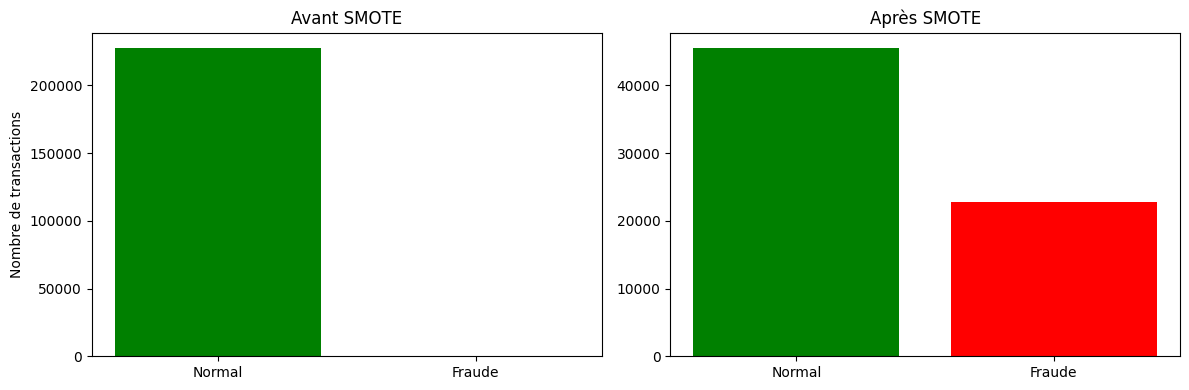

In [3]:
# SMOTE + UnderSampling combinés
over = SMOTE(sampling_strategy=0.1, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

pipeline = Pipeline([('over', over), ('under', under)])
X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print(f"Après SMOTE : {Counter(y_train_res)}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal', 'Fraude'], Counter(y_train).values(), color=['green', 'red'])
axes[0].set_title("Avant SMOTE")
axes[0].set_ylabel("Nombre de transactions")

axes[1].bar(['Normal', 'Fraude'], Counter(y_train_res).values(), color=['green', 'red'])
axes[1].set_title("Après SMOTE")

plt.tight_layout()
plt.show()

In [4]:
import numpy as np

# Sauvegarder pour réutilisation dans les autres notebooks
np.save("../data/X_train_res.npy", X_train_res)
np.save("../data/y_train_res.npy", y_train_res)
np.save("../data/X_test.npy", X_test)
np.save("../data/y_test.npy", y_test)

print(f"✅ Données sauvegardées !")
print(f"X_train rééquilibré : {X_train_res.shape}")
print(f"X_test : {X_test.shape}")

✅ Données sauvegardées !
X_train rééquilibré : (68235, 29)
X_test : (56962, 29)
